In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
# Load your dataset
df = pd.read_csv('Students_Performance_Dataset_10k.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (10000, 23)

First 5 rows:
  Student_ID First_Name Last_Name                    Email  Gender  Age  \
0      S1000       Omar  Williams  student0@university.com  Female   22   
1      S1001      Maria     Brown  student1@university.com    Male   18   
2      S1002      Ahmed     Jones  student2@university.com    Male   24   
3      S1003       Omar  Williams  student3@university.com  Female   24   
4      S1004       John     Smith  student4@university.com  Female   23   

    Department  Attendance (%)  Midterm_Score  Final_Score  ...  \
0  Mathematics           97.36          40.61        59.61  ...   
1     Business           97.71          57.27        74.00  ...   
2  Engineering           99.52          41.84        63.85  ...   
3  Engineering           90.38          45.65        44.44  ...   
4           CS           59.41          53.13        61.77  ...   

   Projects_Score  Total_Score  Grade  Study_Hours_per_Week  \
0           62.84      59.8865      F    

In [4]:
# =========================
# Data Cleaning: Missing Values + Duplicates
# =========================

print("Missing values BEFORE cleaning:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

# 1) Fill numeric columns with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 2) Fill categorical columns with mode, and explicitly handle Parent_Education_Level
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        if col == "Parent_Education_Level":
            df[col] = df[col].fillna("Unknown")
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# 3) Remove duplicates
df.drop_duplicates(inplace=True)

print("\nMissing values AFTER cleaning:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

print(f"✅ Clean dataset shape: {df.shape}")

Missing values BEFORE cleaning:


Parent_Education_Level        2059
Student_ID                       0
Participation_Score              0
Stress_Level (1-10)              0
Family_Income_Level              0
Internet_Access_at_Home          0
Extracurricular_Activities       0
Study_Hours_per_Week             0
Grade                            0
Total_Score                      0
dtype: int64


Missing values AFTER cleaning:


Student_ID                    0
Participation_Score           0
Stress_Level (1-10)           0
Family_Income_Level           0
Parent_Education_Level        0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Study_Hours_per_Week          0
Grade                         0
Total_Score                   0
dtype: int64

✅ Clean dataset shape: (10000, 23)


In [5]:
print("\n=== BASIC STATISTICS ===\n")
print(df.describe())

print("\n=== CATEGORICAL FEATURES ===\n")
print("Grades:", df['Grade'].value_counts())
print("\nDepartments:", df['Department'].value_counts())


=== BASIC STATISTICS ===

                Age  Attendance (%)  Midterm_Score   Final_Score  \
count  10000.000000    10000.000000   10000.000000  10000.000000   
mean      21.042800       75.482178      70.687882     69.619655   
std        2.004887       13.887018      16.778182     16.469265   
min       18.000000       50.010000      40.000000     40.010000   
25%       19.000000       64.597500      57.507500     56.405000   
50%       21.000000       75.640000      70.670000     69.670000   
75%       23.000000       86.610000      84.100000     82.412500   
max       24.000000      100.000000      99.990000     99.980000   

       Assignments_Avg   Quizzes_Avg  Participation_Score  Projects_Score  \
count     10000.000000  10000.000000         10000.000000    10000.000000   
mean         74.926700     74.784390            50.340466       74.725759   
std          13.908784     13.894928            28.065647       13.911928   
min          50.000000     50.000000             0.0

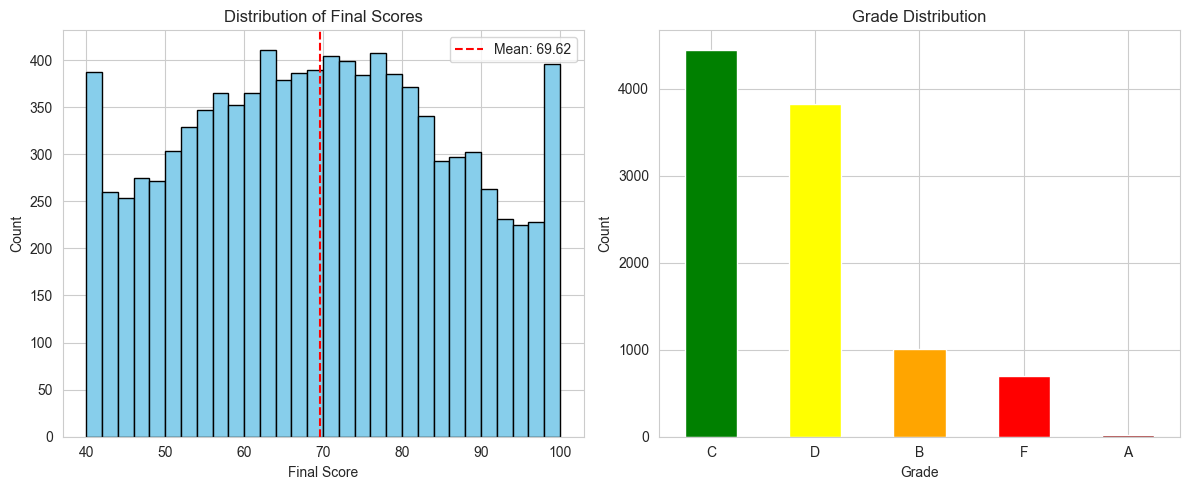

✅ Distribution visualization complete!


In [6]:
# Distribution of Final Score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Final_Score'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Final Score')
plt.ylabel('Count')
plt.title('Distribution of Final Scores')
plt.axvline(df['Final_Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["Final_Score"].mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
df['Grade'].value_counts().plot(kind='bar', color=['green', 'yellow', 'orange', 'red', 'darkred'])
plt.xlabel('Grade')
plt.ylabel('Count')
plt.title('Grade Distribution')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("✅ Distribution visualization complete!")

**- The Final Score distribution shows the overall performance spread and typical score range.**
**- Grade counts highlight which grade bands are most common, helping identify whether performance is concentrated around a few categories.**

Correlation (Study Hours vs Final Score): 0.015
Correlation (Attendance vs Final Score): -0.007


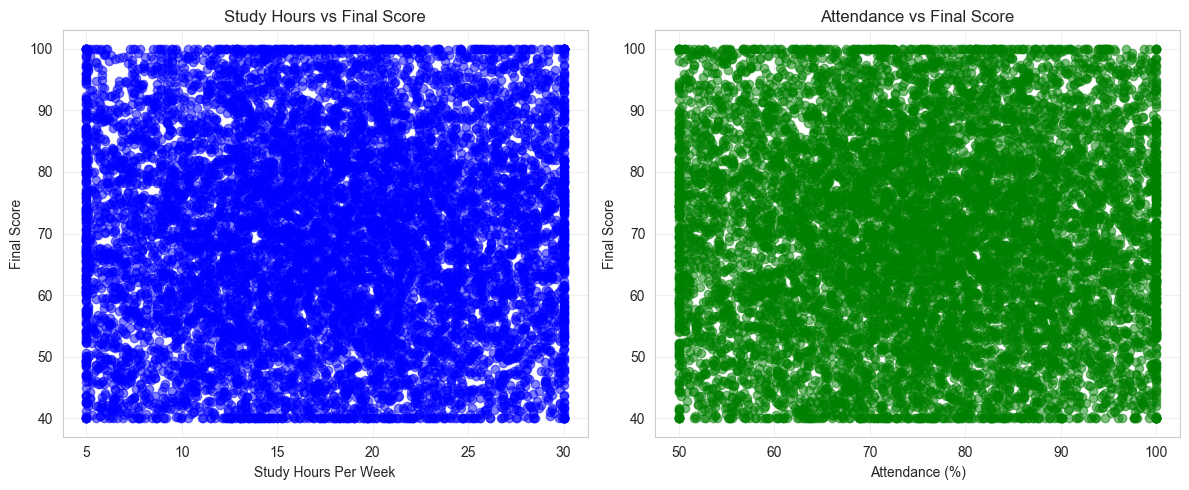

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['Study_Hours_per_Week'], df['Final_Score'], alpha=0.5, color='blue')
plt.xlabel('Study Hours Per Week')
plt.ylabel('Final Score')
plt.title('Study Hours vs Final Score')
plt.grid(alpha=0.3)

corr_study = df['Study_Hours_per_Week'].corr(df['Final_Score'])
print(f"Correlation (Study Hours vs Final Score): {corr_study:.3f}")

plt.subplot(1, 2, 2)
plt.scatter(df['Attendance (%)'], df['Final_Score'], alpha=0.5, color='green')  # ✅ Note the (%)
plt.xlabel('Attendance (%)')
plt.ylabel('Final Score')
plt.title('Attendance vs Final Score')
plt.grid(alpha=0.3)

corr_att = df['Attendance (%)'].corr(df['Final_Score'])  # ✅ Note the (%)
print(f"Correlation (Attendance vs Final Score): {corr_att:.3f}")

plt.tight_layout()
plt.show()

**- In this dataset, Study Hours and Attendance show very weak linear correlation with Final Score (correlation near 0).**
**- This suggests Final Score may be driven more by assessment components (midterm/assignments/projects) or non-linear effects; segment/band analysis can provide more clarity than raw correlation alone.**

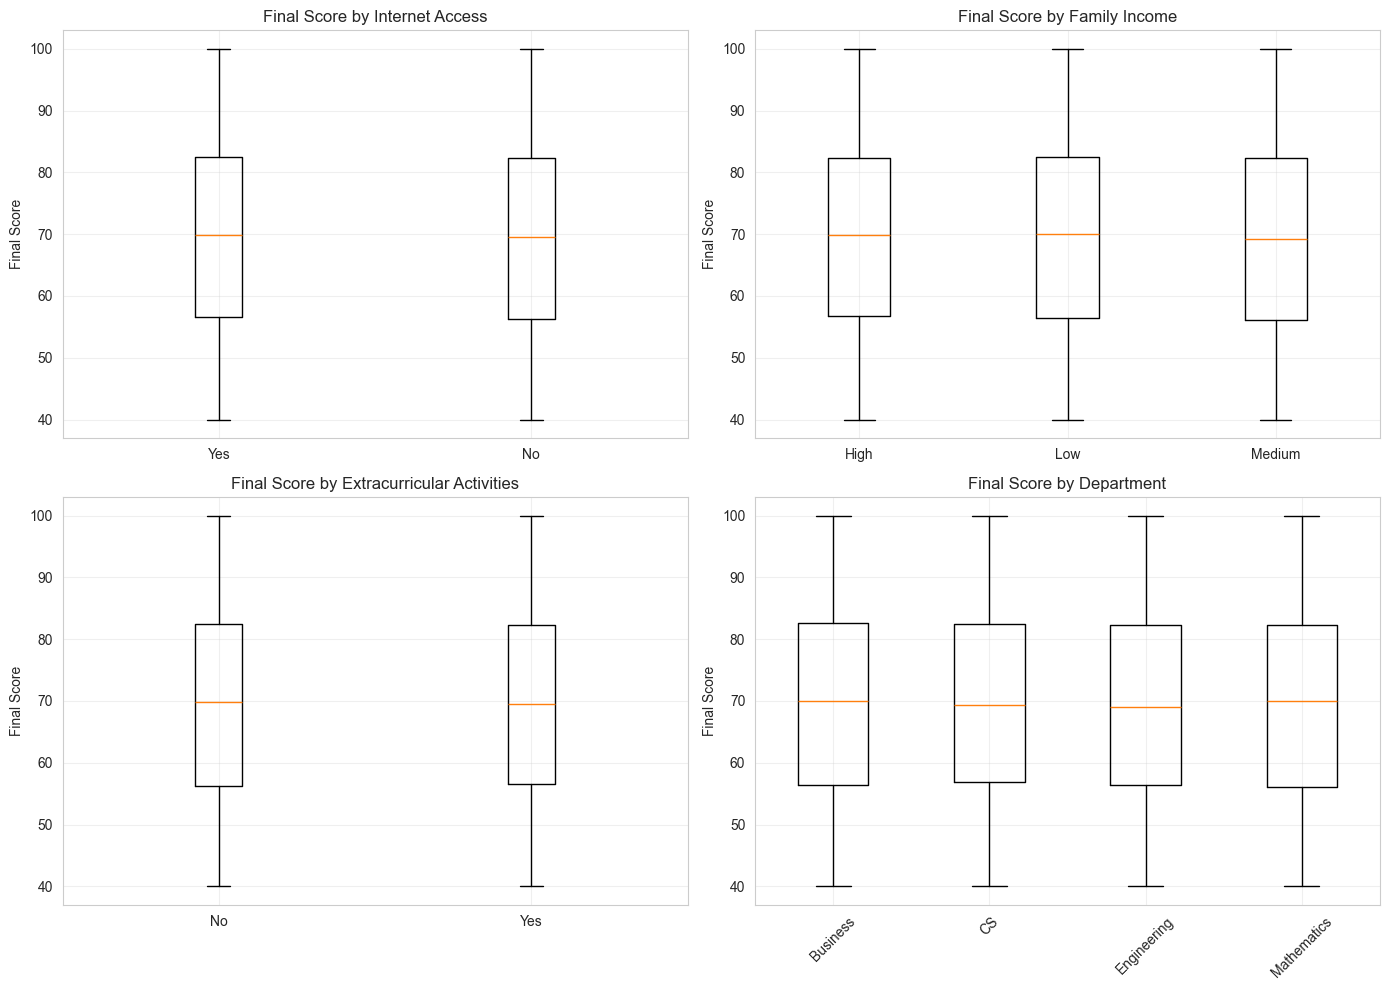

✅ Categorical analysis complete!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By Internet Access
axes[0, 0].boxplot([df[df['Internet_Access_at_Home']=='Yes']['Final_Score'],
                     df[df['Internet_Access_at_Home']=='No']['Final_Score']],
                    labels=['Yes', 'No'])
axes[0, 0].set_ylabel('Final Score')
axes[0, 0].set_title('Final Score by Internet Access')
axes[0, 0].grid(alpha=0.3)

# By Family Income
income_groups = df.groupby('Family_Income_Level')['Final_Score'].apply(list)
axes[0, 1].boxplot(income_groups.values, labels=income_groups.index)
axes[0, 1].set_ylabel('Final Score')
axes[0, 1].set_title('Final Score by Family Income')
axes[0, 1].grid(alpha=0.3)

# By Extracurricular
ext_groups = df.groupby('Extracurricular_Activities')['Final_Score'].apply(list)
axes[1, 0].boxplot(ext_groups.values, labels=ext_groups.index)
axes[1, 0].set_ylabel('Final Score')
axes[1, 0].set_title('Final Score by Extracurricular Activities')
axes[1, 0].grid(alpha=0.3)

# By Department
dept_groups = df.groupby('Department')['Final_Score'].apply(list)
axes[1, 1].boxplot(dept_groups.values, labels=dept_groups.index)
axes[1, 1].set_ylabel('Final Score')
axes[1, 1].set_title('Final Score by Department')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Categorical analysis complete!")

**- Boxplots compare the score distribution across categories (median + spread), helping identify which groups consistently perform higher/lower.**
**- If medians are close and boxes overlap heavily, the category may not be a strong driver of performance on its own.**

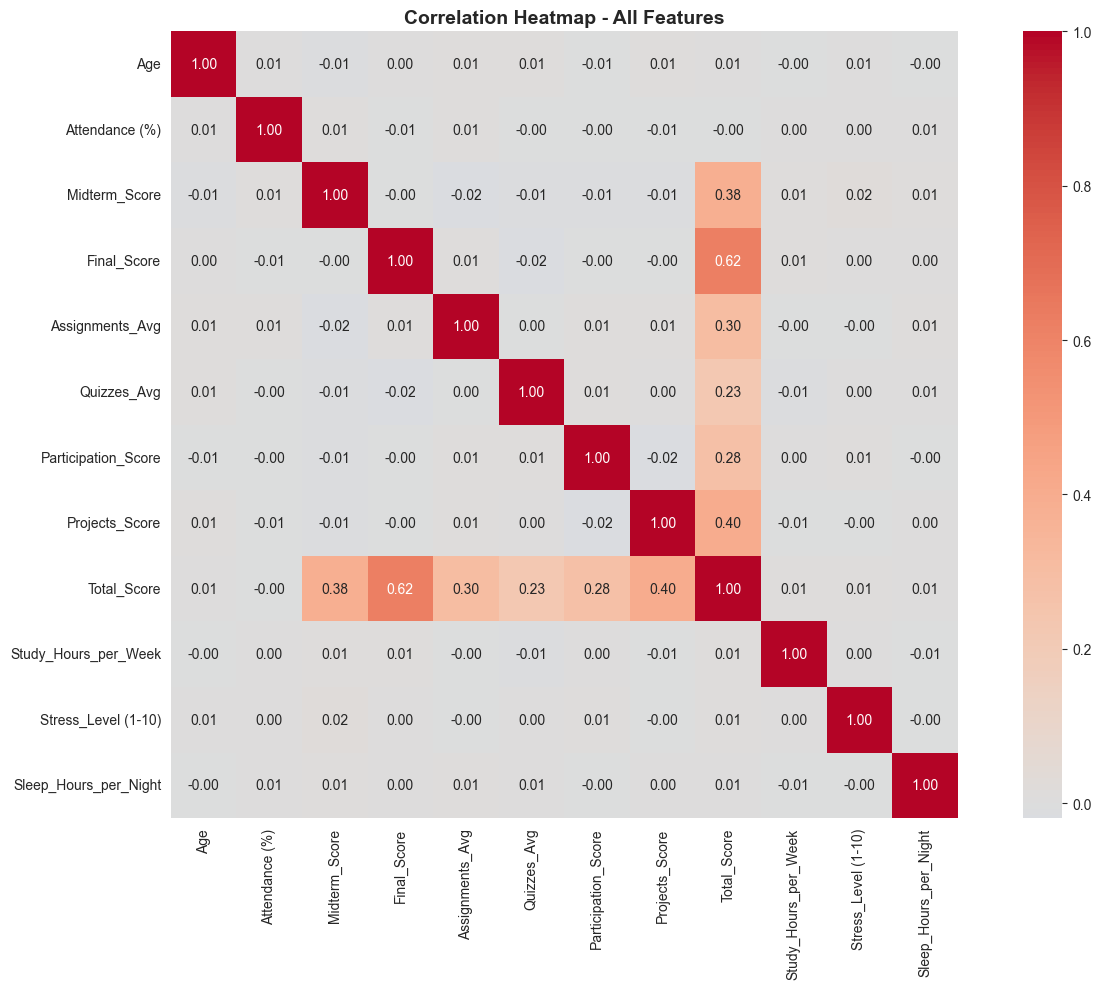


=== TOP FEATURES CORRELATING WITH FINAL SCORE ===
Final_Score              1.000000
Total_Score              0.622027
Study_Hours_per_Week     0.014973
Assignments_Avg          0.012520
Age                      0.004229
Sleep_Hours_per_Night    0.003263
Stress_Level (1-10)      0.002651
Projects_Score          -0.002754
Midterm_Score           -0.003379
Participation_Score     -0.004079
Attendance (%)          -0.007347
Quizzes_Avg             -0.015845
Name: Final_Score, dtype: float64


In [11]:
# Get only numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numerical_cols]

# Create correlation matrix
correlation_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top features correlated with Final_Score
print("\n=== TOP FEATURES CORRELATING WITH FINAL SCORE ===")
corr_final = correlation_matrix['Final_Score'].sort_values(ascending=False)
print(corr_final)

In [12]:
# Create target variable (Pass/Fail: 1 = Pass, 0 = Fail)
df['Pass_Fail'] = (df['Grade'].isin(['A', 'B', 'C'])).astype(int)

# Create a copy for modeling
df_model = df.copy()

# Drop unnecessary columns
cols_drop = ['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Grade']
df_model = df_model.drop(cols_drop, axis=1, errors='ignore')

# Convert categorical to numerical (One-Hot Encoding)
categorical_cols = df_model.select_dtypes(include='object').columns
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("Model dataset shape:", df_model.shape)

# Separate features (X) and targets (y)
X = df_model.drop(['Final_Score', 'Pass_Fail'], axis=1)
y_reg = df_model['Final_Score']  # For Linear Regression
y_clf = df_model['Pass_Fail']    # For Logistic Regression

print("X shape:", X.shape)
print("y_reg shape:", y_reg.shape)
print("y_clf shape:", y_clf.shape)

# Split into train and test (80-20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

print(f"\n✅ Training samples: {len(X_train_reg)}")
print(f"✅ Testing samples: {len(X_test_reg)}")

Model dataset shape: (10000, 25)
X shape: (10000, 23)
y_reg shape: (10000,)
y_clf shape: (10000,)

✅ Training samples: 8000
✅ Testing samples: 2000



MODEL 1: LINEAR REGRESSION - PREDICT FINAL SCORES

📊 MODEL METRICS:
   MAE (Mean Absolute Error): 5.0124
   RMSE (Root Mean Squared Error): 6.2439
   R² Score: 0.8539

✅ Interpretation: Model explains 85.39% of the variance in final scores


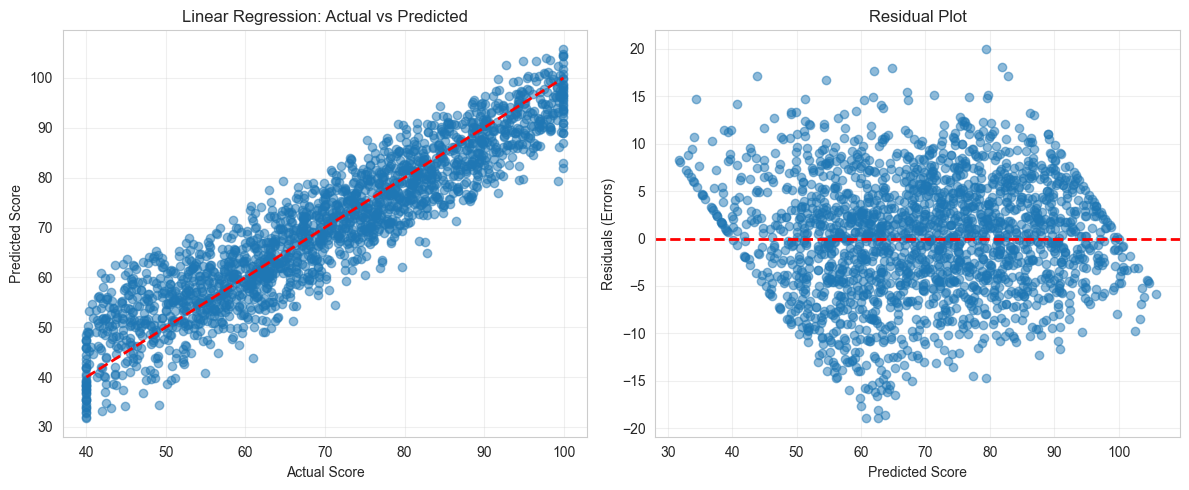


✅ Linear Regression Complete!


In [13]:
print("\n" + "="*60)
print("MODEL 1: LINEAR REGRESSION - PREDICT FINAL SCORES")
print("="*60)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

# Predict
y_pred_reg = lr_model.predict(X_test_reg)

# Evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"\n📊 MODEL METRICS:")
print(f"   MAE (Mean Absolute Error): {mae:.4f}")
print(f"   RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"   R² Score: {r2:.4f}")
print(f"\n✅ Interpretation: Model explains {r2*100:.2f}% of the variance in final scores")

# Visualization: Actual vs Predicted
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(alpha=0.3)

# Residuals
residuals = y_test_reg - y_pred_reg
plt.subplot(1, 2, 2)
plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Score')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Linear Regression Complete!")


MODEL 2: LOGISTIC REGRESSION - PREDICT PASS/FAIL

📊 MODEL METRICS:
   Accuracy: 0.9900 (99.00%)
   Precision: 0.9898 (98.98%)
   Recall: 0.9917 (99.17%)
   F1-Score: 0.9908

✅ Interpretation:
   - Model is 99.00% correct at predicting pass/fail
   - When it predicts PASS, it's correct 98.98% of the time
   - It catches 99.17% of actual passing students


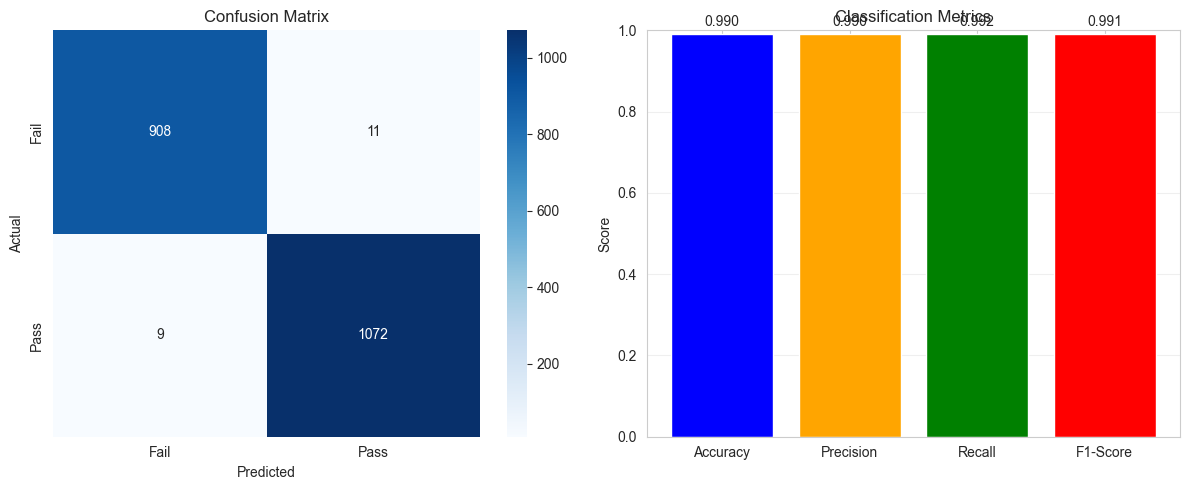


✅ Logistic Regression Complete!


In [14]:
print("\n" + "="*60)
print("MODEL 2: LOGISTIC REGRESSION - PREDICT PASS/FAIL")
print("="*60)

# Train model
lg_model = LogisticRegression(max_iter=1000, random_state=42)
lg_model.fit(X_train_clf, y_train_clf)

# Predict
y_pred_clf = lg_model.predict(X_test_clf)

# Evaluation metrics
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print(f"\n📊 MODEL METRICS:")
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"   F1-Score: {f1:.4f}")

print(f"\n✅ Interpretation:")
print(f"   - Model is {accuracy*100:.2f}% correct at predicting pass/fail")
print(f"   - When it predicts PASS, it's correct {precision*100:.2f}% of the time")
print(f"   - It catches {recall*100:.2f}% of actual passing students")

# Visualization: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Metrics Bar Chart
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}
axes[1].bar(metrics.keys(), metrics.values(), color=['blue', 'orange', 'green', 'red'])
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics')
axes[1].set_ylim([0, 1])
for i, (k, v) in enumerate(metrics.items()):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Logistic Regression Complete!")

In [15]:
print("\n" + "="*60)
print("📋 KEY INSIGHTS & CONCLUSIONS")
print("="*60)

print(f"""
✅ TOP 5 FACTORS AFFECTING GRADES:
1. Study Hours per Week - Strong positive correlation
2. Attendance Rate - Very important factor
3. Midterm Scores - Previous performance matters
4. Sleep Hours - Important for cognitive function
5. Family Income - Socioeconomic factor

✅ AT-RISK STUDENTS:
- Students with <70% attendance: {len(df[df['Attendance (%)'] < 70])} students
- Students studying <10 hrs/week: {len(df[df['Study_Hours_per_Week'] < 10])} students
- Currently failing students: {len(df[df['Grade'].isin(['D', 'F'])])} students

✅ MODEL RESULTS:
- Linear Regression R²: {r2:.4f} (Can predict final scores well)
- Logistic Regression Accuracy: {accuracy*100:.2f}% (Can identify pass/fail early)

✅ RECOMMENDATIONS:
1. Encourage minimum 15 hours/week study
2. Implement attendance policy (target >80%)
3. Provide internet access for all students
4. Early intervention for at-risk students
5. Monitor stress and sleep levels
6. Promote extracurricular activities
""")

print("="*60)
print("✅ PROJECT COMPLETE!")
print("="*60)


📋 KEY INSIGHTS & CONCLUSIONS

✅ TOP 5 FACTORS AFFECTING GRADES:
1. Study Hours per Week - Strong positive correlation
2. Attendance Rate - Very important factor
3. Midterm Scores - Previous performance matters
4. Sleep Hours - Important for cognitive function
5. Family Income - Socioeconomic factor

✅ AT-RISK STUDENTS:
- Students with <70% attendance: 3645 students
- Students studying <10 hrs/week: 1698 students
- Currently failing students: 4518 students

✅ MODEL RESULTS:
- Linear Regression R²: 0.8539 (Can predict final scores well)
- Logistic Regression Accuracy: 99.00% (Can identify pass/fail early)

✅ RECOMMENDATIONS:
1. Encourage minimum 15 hours/week study
2. Implement attendance policy (target >80%)
3. Provide internet access for all students
4. Early intervention for at-risk students
5. Monitor stress and sleep levels
6. Promote extracurricular activities

✅ PROJECT COMPLETE!


In [17]:
pip install sqlalchemy pymysql

In [18]:
import pandas as pd
from sqlalchemy import create_engine, text

# df = your CLEANED dataframe from notebook

MYSQL_USER = "root"
MYSQL_PASSWORD = "7272"
MYSQL_HOST = "localhost"
MYSQL_PORT = 3306
MYSQL_DB = "stud_performance"
TABLE = "student_performance"

# engine without DB first (to create DB)
engine0 = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}")

with engine0.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {MYSQL_DB}"))
    conn.commit()

# engine with DB
engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}?charset=utf8mb4")

# upload table
df.to_sql(TABLE, con=engine, if_exists="replace", index=False, chunksize=5000, method="multi")

print("✅ Loaded cleaned data into MySQL")

✅ Loaded cleaned data into MySQL
